List of pigments:

* Phthalo	Blue (Green Shade), PB 15:4, Copper Phthalocyanine
* Quinacridone Magenta, PR 122, Quinacridone
* Hansa Yellow, PY 74, Benzimidazolone Yellow
* Titanium White, PW 6, Titanium Dioxide

http://www.goldenpaints.com/products/colors/heavy-body


# Setup

In [1]:
# Attempt to create a perceptually uniform mixing space by applying a bias to the
# interpolation parameter.
PERCEPTUAL_MIX = False

In [2]:
%reload_ext autoreload
%autoreload 1
%aimport pigments

In [3]:
# @title Imports
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pigments

# Mixing

In [4]:
# @title Setup pigments
pg = pigments.Pigments(pigments.load_config_from_json("config.json"))

[0.         0.56633399 0.43366601 0.        ]


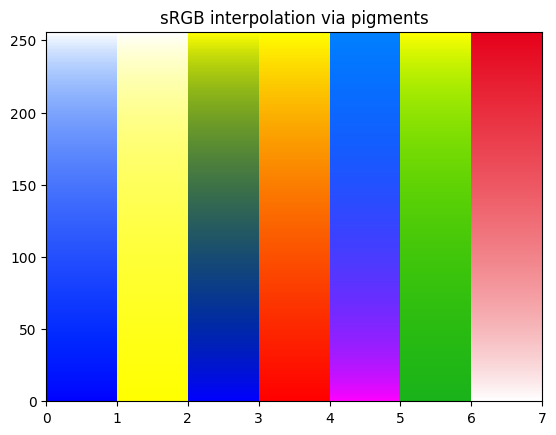

In [ ]:
# @title Interpolation from RGB
ig, ax = plt.subplots()

rgb1 = [
    [0.0, 0.0, 1.0],
    [1.0, 1.0, 0.0],
    [0.0, 0.0, 1.0],
    [1.0, 0.0, 0.0],
    [1.0, 0.0, 1.0],
    [0.1, 0.7, 0.1],
    [1.0, 1.0, 1.0],
]
rgb2 = [
    [1.0, 1.0, 1.0],
    [1.0, 1.0, 1.0],
    [1.0, 1.0, 0.0],
    [1.0, 1.0, 0.0],
    [0.0, 0.5, 1.0],
    [1.0, 1.0, 0.0],
    [0.9, 0.0, 0.1],
]

patchCount = 256

for k in range(len(rgb1)):
    c1 = pg.unmix(rgb1[k])
    r1 = rgb1[k] - pg.mix(c1)

    c2 = pg.unmix(rgb2[k])
    r2 = rgb2[k] - pg.mix(c2)

    # Only used with PERCEPTUAL_MIX set to True
    linear_rgb1 = np.array([i ** 2.2 for i in rgb1[k]])
    linear_rgb2 = np.array([i ** 2.2 for i in rgb2[k]])
    l1 = np.dot(linear_rgb1, [0.2126, 0.7152, 0.0722]) ** 0.5
    l2 = np.dot(linear_rgb2, [0.2126, 0.7152, 0.0722]) ** 0.5
    bias = l2 / (l1 + l2)

    for j in range(patchCount):
        t = j / (patchCount - 1.0)
        t_perceptual = t / ((1 / bias - 2) * (1 - t) + 1)

        rgb = pg.latent_lerp(c1, r1, c2, r2, t_perceptual if PERCEPTUAL_MIX else t)

        ax.add_patch(
            patches.Rectangle(
                (k, j), 1, 1,
                facecolor=np.clip(rgb, 0.0, 1.0)
            )
        )

ax.set_xlim(0, len(rgb1))
ax.set_ylim(0, patchCount)

plt.title('sRGB interpolation via pigments')
plt.show()

# Pigments Optimization

In [6]:
# @title Adam optimization of surrogate pigments
if not pg.config.use_optimized_pigments:
    pg.optimize_pigments()
